# CoT causal alignment

## Deterministic reasoning trajectory

Generate one clean reasoning trajectory with thinking enabled. Print the complete trajectory and every generated token position for manual inspection.

In [2]:
import random

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 0
MODEL_NAME = "Qwen/Qwen3-0.6B"
MAX_NEW_TOKENS = 500

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
)
model.eval()

messages = [{
    "role": "user",
    "content": """Alice is older than Bob.
Bob is older than Charlie.

Who is the oldest?
Explain your reasoning and give the final answer.""",
}]

prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

prompt_length = inputs["input_ids"].shape[-1]
generated_ids = output_ids[0, prompt_length:]
trajectory = tokenizer.decode(generated_ids, skip_special_tokens=False)
generated_tokens = tokenizer.convert_ids_to_tokens(generated_ids.tolist())

print(f"model={MODEL_NAME} seed={SEED} do_sample=False max_new_tokens={MAX_NEW_TOKENS}")
print("\n=== COMPLETE GENERATED TRAJECTORY ===")
print(trajectory)
print("\n=== GENERATED TOKEN POSITIONS ===")
for position, token in enumerate(generated_tokens):
    print(f"{position:03d}\t{token!r}")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

model=Qwen/Qwen3-0.6B seed=0 do_sample=False max_new_tokens=500

=== COMPLETE GENERATED TRAJECTORY ===
<think>
Okay, let's see. The problem says Alice is older than Bob, and Bob is older than Charlie. I need to figure out who is the oldest among them. Hmm, so first, I should probably list out the relationships.

So, Alice > Bob, and Bob > Charlie. That means starting from the top, Alice is the oldest, then Bob, then Charlie. So if I imagine a line of ages, Alice is first, Bob second, and Charlie third. Therefore, the oldest would be Alice. But wait, maybe there's something else I'm missing? Like, could there be a case where someone is older than both? But according to the given statements, Alice is older than Bob, and Bob is older than Charlie. So there's no overlap in their ages beyond those two. So Alice must be the oldest. 

Wait, but maybe there's a trick here. Like, if they are all in a group, but the problem doesn't mention any other people. So the answer should be Alice. Let me 

## Semantic checkpoints

Inspect repeated reasoning events before selecting the spans used below.

In [3]:
event_candidates = {
    "Premise restatement": [
        (11, 22),
        (51, 58),
        (139, 150),
        (214, 220),
    ],
    "Integrated relation": [
        (51, 76),
        (87, 96),
        (214, 230),
    ],
    "Decision": [
        (67, 70),
        (98, 104),
        (164, 169),
        (202, 207),
        (231, 236),
    ],
}

think_end = generated_tokens.index("</think>")
for event_name, candidates in event_candidates.items():
    for candidate_number, (start, end) in enumerate(candidates, start=1):
        assert 0 <= start <= end < think_end
        span_text = tokenizer.decode(generated_ids[start:end + 1], skip_special_tokens=False)
        print(f"{event_name} — candidate {candidate_number}")
        print(f"start={start}, end={end}")
        print(span_text)
        print()

Premise restatement — candidate 1
start=11, end=22
 Alice is older than Bob, and Bob is older than Charlie

Premise restatement — candidate 2
start=51, end=58
 Alice > Bob, and Bob > Charlie

Premise restatement — candidate 3
start=139, end=150
 Alice is older than Bob, and Bob is older than Charlie

Premise restatement — candidate 4
start=214, end=220
 Alice > Bob, Bob > Charlie

Integrated relation — candidate 1
start=51, end=76
 Alice > Bob, and Bob > Charlie. That means starting from the top, Alice is the oldest, then Bob, then Charlie

Integrated relation — candidate 2
start=87, end=96
 Alice is first, Bob second, and Charlie third

Integrated relation — candidate 3
start=214, end=230
 Alice > Bob, Bob > Charlie. So yes, Alice is older than both.

Decision — candidate 1
start=67, end=70
 Alice is the oldest

Decision — candidate 2
start=98, end=104
 Therefore, the oldest would be Alice

Decision — candidate 3
start=164, end=169
 So Alice must be the oldest

Decision — candidate 4


## Answer preference through the reasoning trajectory

Measure the Alice-Bob next-token logit difference through the teacher-forced clean CoT. This readout depends strongly on local context and is not causal evidence.

Premise restatement: before start t=10, D_t=11.687500
Premise restatement: end t=22, D_t=-1.859375
Integrated relation: before start t=50, D_t=10.125000
Integrated relation: end t=58, D_t=0.812500
Decision: before start t=66, D_t=7.000000
Decision: end t=70, D_t=0.875000


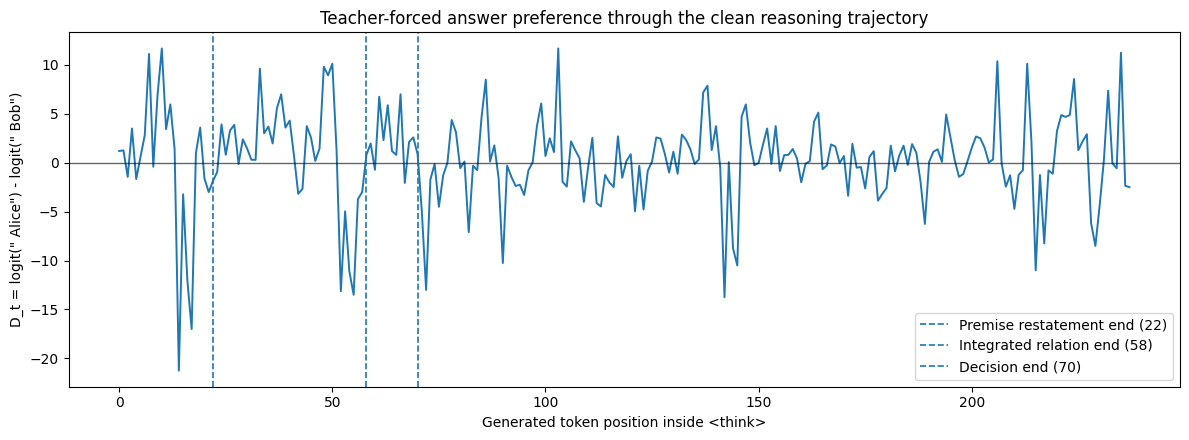

In [4]:
import matplotlib.pyplot as plt

selected_checkpoints = {
    "Premise restatement": (11, 22),
    "Integrated relation": (51, 58),
    "Decision": (67, 70),
}

alice_ids = tokenizer.encode(" Alice", add_special_tokens=False)
bob_ids = tokenizer.encode(" Bob", add_special_tokens=False)
assert len(alice_ids) == len(bob_ids) == 1
alice_token_id, bob_token_id = alice_ids[0], bob_ids[0]

with torch.inference_mode():
    teacher_forced_logits = model(output_ids).logits[0]

reasoning_positions = list(range(think_end))
sequence_positions = torch.arange(
    prompt_length, prompt_length + think_end, device=teacher_forced_logits.device
)
answer_preference = (
    teacher_forced_logits[sequence_positions, alice_token_id]
    - teacher_forced_logits[sequence_positions, bob_token_id]
).float().cpu()

for event_name, (start, end) in selected_checkpoints.items():
    before = start - 1
    print(f"{event_name}: before start t={before}, D_t={answer_preference[before].item():.6f}")
    print(f"{event_name}: end t={end}, D_t={answer_preference[end].item():.6f}")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(reasoning_positions, answer_preference.numpy(), linewidth=1.4)
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
for event_name, (_, end) in selected_checkpoints.items():
    ax.axvline(end, linestyle="--", linewidth=1.2, label=f"{event_name} end ({end})")
ax.set_xlabel("Generated token position inside <think>")
ax.set_ylabel('D_t = logit(" Alice") - logit(" Bob")')
ax.set_title("Teacher-forced answer preference through the clean reasoning trajectory")
ax.legend()
plt.tight_layout()
plt.show()

## Final-answer readout sanity check

Measure the Alice-Bob logit difference immediately before the final answer token.

In [5]:
final_answer_token_position = 281
readout_position = final_answer_token_position - 1
assert tokenizer.decode(generated_ids[final_answer_token_position:final_answer_token_position + 1]) == " Alice"

sequence_readout_position = prompt_length + readout_position
alice_logit = teacher_forced_logits[sequence_readout_position, alice_token_id].item()
bob_logit = teacher_forced_logits[sequence_readout_position, bob_token_id].item()
surrounding_text = tokenizer.decode(
    generated_ids[max(0, readout_position - 8):min(len(generated_ids), final_answer_token_position + 2)],
    skip_special_tokens=False,
)

print(f"Generated-token readout position: {readout_position}")
print(f"Surrounding text: {surrounding_text!r}")
print(f'logit(" Alice"): {alice_logit:.6f}')
print(f'logit(" Bob"): {bob_logit:.6f}')
print(f"D: {alice_logit - bob_logit:.6f}")

Generated-token readout position: 280
Surrounding text: ' is **Alice**.\n\n**Final Answer:** Alice.'
logit(" Alice"): 25.750000
logit(" Bob"): 11.875000
D: 13.875000


## Checkpoint-to-answer activation patching

Patch each checkpoint state into the final-answer position and measure the Alice-Bob logit difference. This exploratory cross-position intervention does not test whether a verbalized statement was necessary.

/tmp/ipykernel_706/793571578.py:4: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  tl_model = HookedTransformer.from_pretrained(MODEL_NAME)


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
Unpatched final-readout baseline D: 13.701447

D_patch by checkpoint and layer:
layer                      0         1         2         3         4         5         6         7         8         9        10       11        12        13        14        15        16        17        18        19       20        21        22        23        24        25        26        27
checkpoint                                                                                                                                                                                                                                                                                              
Premise restatement -0.476101 -0.703022 -1.217899 -1.258228 -1.932570 -2.104782 -2.156982 -1.992729 -1.254498 -0.761508 0.532109 0.370440 -0.150586  0.418951  0.521861 -0.408144 -0.759926 -0.216692 -1.432829 -0.316592 0.748645 -0.663202 -2.254642 -1.942726 -1.986

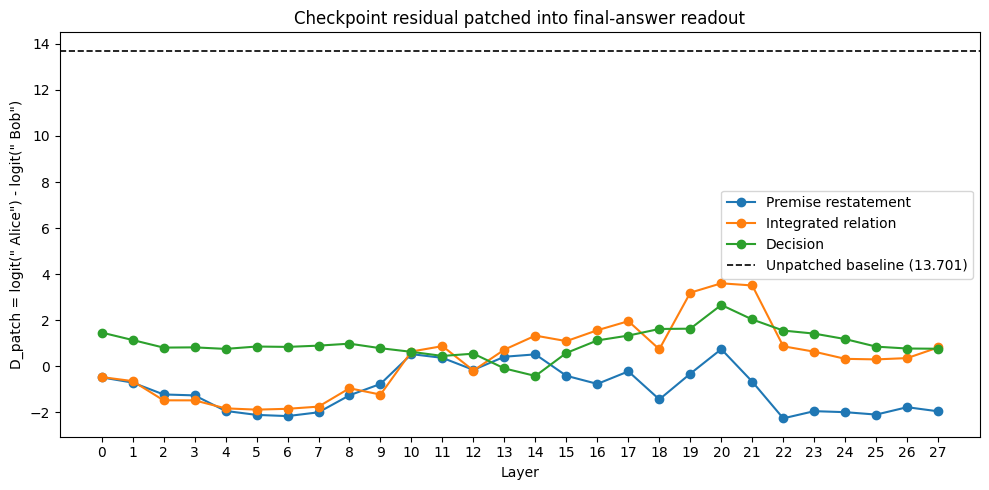

In [6]:
import pandas as pd
from transformer_lens import HookedTransformer

tl_model = HookedTransformer.from_pretrained(MODEL_NAME)
tl_model.eval()

checkpoint_ends = {
    "Premise restatement": 22,
    "Integrated relation": 58,
    "Decision": 70,
}
full_tokens = output_ids.to(tl_model.cfg.device)
readout_sequence_position = prompt_length + readout_position
checkpoint_sequence_positions = {
    name: prompt_length + position for name, position in checkpoint_ends.items()
}
tl_alice_token_id = tl_model.to_single_token(" Alice")
tl_bob_token_id = tl_model.to_single_token(" Bob")
assert tl_alice_token_id == alice_token_id
assert tl_bob_token_id == bob_token_id
assert full_tokens[0, readout_sequence_position + 1].item() == tl_alice_token_id

with torch.inference_mode():
    baseline_logits, clean_resid_cache = tl_model.run_with_cache(
        full_tokens,
        names_filter=lambda name: name.endswith("hook_resid_post"),
    )

baseline_D = (
    baseline_logits[0, readout_sequence_position, tl_alice_token_id]
    - baseline_logits[0, readout_sequence_position, tl_bob_token_id]
).item()

patch_rows = []
with torch.inference_mode():
    for checkpoint_name, checkpoint_position in checkpoint_sequence_positions.items():
        for layer in range(tl_model.cfg.n_layers):
            hook_name = f"blocks.{layer}.hook_resid_post"
            source_vector = clean_resid_cache[hook_name][0, checkpoint_position].detach().clone()

            def patch_checkpoint_into_readout(activation, hook, source=source_vector):
                patched = activation.clone()
                patched[0, readout_sequence_position] = source
                return patched

            patched_logits = tl_model.run_with_hooks(
                full_tokens,
                fwd_hooks=[(hook_name, patch_checkpoint_into_readout)],
            )
            D_patch = (
                patched_logits[0, readout_sequence_position, tl_alice_token_id]
                - patched_logits[0, readout_sequence_position, tl_bob_token_id]
            ).item()
            patch_rows.append({
                "checkpoint": checkpoint_name,
                "layer": layer,
                "D_patch": D_patch,
            })

patch_results = pd.DataFrame(patch_rows)
patch_table = patch_results.pivot(index="checkpoint", columns="layer", values="D_patch").loc[
    list(checkpoint_ends)
]
print(f"Unpatched final-readout baseline D: {baseline_D:.6f}")
print("\nD_patch by checkpoint and layer:")
print(patch_table.to_string(float_format=lambda value: f"{value:.6f}"))

fig, ax = plt.subplots(figsize=(10, 5))
for checkpoint_name in checkpoint_ends:
    checkpoint_results = patch_results[patch_results["checkpoint"] == checkpoint_name]
    ax.plot(checkpoint_results["layer"], checkpoint_results["D_patch"], marker="o", label=checkpoint_name)
ax.axhline(baseline_D, color="black", linestyle="--", linewidth=1.2, label=f"Unpatched baseline ({baseline_D:.3f})")
ax.set_xticks(range(tl_model.cfg.n_layers))
ax.set_xlabel("Layer")
ax.set_ylabel('D_patch = logit(" Alice") - logit(" Bob")')
ax.set_title("Checkpoint residual patched into final-answer readout")
ax.legend()
plt.tight_layout()
plt.show()

## Position-matched branch candidates

Sample 20 on-policy branches before the integrated-relation event; all repeated the clean relation, so no position-matched counterfactual was found.

In [7]:
integrated_start, integrated_end = 51, 58
branch_prefix_ids = output_ids[:, :prompt_length + integrated_start]

decoded_prefix = tokenizer.decode(generated_ids[:integrated_start], skip_special_tokens=False)
decoded_clean_event = tokenizer.decode(generated_ids[integrated_start:integrated_end + 1], skip_special_tokens=False)
decoded_clean_continuation = tokenizer.decode(generated_ids[integrated_end + 1:think_end + 1], skip_special_tokens=False)

print("=== PREFIX THROUGH GENERATED TOKEN 50 ===")
print(decoded_prefix)
print("\n=== CLEAN EVENT, GENERATED TOKENS 51–58 ===")
print(decoded_clean_event)
print("\n=== CLEAN CONTINUATION AFTER TOKEN 58 THROUGH </think> ===")
print(decoded_clean_continuation)

BRANCH_SEEDS = [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010,
                1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020]
SAMPLING_PARAMETERS = {
    "max_new_tokens": 300,
    "do_sample": True,
    "temperature": 0.6,
    "top_p": 0.95,
    "top_k": 20,
    "repetition_penalty": 1.0,
    "pad_token_id": tokenizer.eos_token_id,
}
PREVIEW_TOKENS = 40

print(f"\nSeeds: {BRANCH_SEEDS}")
print(f"Sampling parameters: {SAMPLING_PARAMETERS}")
branch_candidates = []
for candidate_number, seed in enumerate(BRANCH_SEEDS, start=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    with torch.inference_mode():
        candidate_output = model.generate(
            input_ids=branch_prefix_ids,
            attention_mask=torch.ones_like(branch_prefix_ids),
            **SAMPLING_PARAMETERS,
        )

    candidate_ids = candidate_output[0, branch_prefix_ids.shape[1]:]
    candidate_text = tokenizer.decode(candidate_ids, skip_special_tokens=False)
    preview_text = tokenizer.decode(candidate_ids[:PREVIEW_TOKENS], skip_special_tokens=False)
    if "</think>" in candidate_text:
        final_answer = candidate_text.split("</think>", 1)[1].replace("<|im_end|>", "").strip()
    else:
        final_answer = "[no final answer generated]"

    branch_candidates.append({
        "candidate": candidate_number,
        "seed": seed,
        "token_ids": candidate_ids.cpu(),
        "text": candidate_text,
        "preview": preview_text,
        "final_answer": final_answer,
    })
    print(f"\n=== CANDIDATE {candidate_number:02d} | seed={seed} ===")
    print(f"First {min(PREVIEW_TOKENS, len(candidate_ids))} generated tokens:")
    print(preview_text)
    print("Final answer:")
    print(final_answer)

=== PREFIX THROUGH GENERATED TOKEN 50 ===
<think>
Okay, let's see. The problem says Alice is older than Bob, and Bob is older than Charlie. I need to figure out who is the oldest among them. Hmm, so first, I should probably list out the relationships.

So,

=== CLEAN EVENT, GENERATED TOKENS 51–58 ===
 Alice > Bob, and Bob > Charlie

=== CLEAN CONTINUATION AFTER TOKEN 58 THROUGH </think> ===
. That means starting from the top, Alice is the oldest, then Bob, then Charlie. So if I imagine a line of ages, Alice is first, Bob second, and Charlie third. Therefore, the oldest would be Alice. But wait, maybe there's something else I'm missing? Like, could there be a case where someone is older than both? But according to the given statements, Alice is older than Bob, and Bob is older than Charlie. So there's no overlap in their ages beyond those two. So Alice must be the oldest. 

Wait, but maybe there's a trick here. Like, if they are all in a group, but the problem doesn't mention any other 

## Prompt-state intervention

Patch the corrupted relation-token state into the clean prompt prefill and generate normally. This is close to a latent input intervention, not evidence that verbalized CoT is causally necessary.

In [8]:
import re

INTERVENTION_LAYERS = [0, 1, 2, 3, 5, 10]
GENERATION_SEED = 0
GENERATION_MAX_NEW_TOKENS = 500

clean_generation_user_prompt = """Alice is older than Bob.
Bob is older than Charlie.

Who is the oldest?
Explain your reasoning and give the final answer."""
corrupt_generation_user_prompt = clean_generation_user_prompt.replace("older than Bob", "younger than Bob", 1)

def make_thinking_prompt(user_prompt):
    return tl_model.tokenizer.apply_chat_template(
        [{"role": "user", "content": user_prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=True,
    )

clean_generation_text = make_thinking_prompt(clean_generation_user_prompt)
corrupt_generation_text = make_thinking_prompt(corrupt_generation_user_prompt)
clean_generation_tokens = tl_model.to_tokens(clean_generation_text, prepend_bos=False)
corrupt_generation_tokens = tl_model.to_tokens(corrupt_generation_text, prepend_bos=False)
assert clean_generation_tokens.shape == corrupt_generation_tokens.shape
generation_difference_positions = (
    clean_generation_tokens[0] != corrupt_generation_tokens[0]
).nonzero(as_tuple=False).flatten().tolist()
assert len(generation_difference_positions) == 1, generation_difference_positions
generation_relation_position = generation_difference_positions[0]
assert tl_model.to_string(clean_generation_tokens[0, generation_relation_position]).strip() == "older"
assert tl_model.to_string(corrupt_generation_tokens[0, generation_relation_position]).strip() == "younger"

intervention_hook_names = [f"blocks.{layer}.hook_resid_post" for layer in INTERVENTION_LAYERS]
with torch.inference_mode():
    _, clean_prompt_cache = tl_model.run_with_cache(
        clean_generation_tokens, names_filter=intervention_hook_names
    )
    _, corrupt_prompt_cache = tl_model.run_with_cache(
        corrupt_generation_tokens, names_filter=intervention_hook_names
    )

def generate_with_prompt_patch(prompt_tokens, layer=None):
    torch.manual_seed(GENERATION_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(GENERATION_SEED)

    generation_kwargs = dict(
        max_new_tokens=GENERATION_MAX_NEW_TOKENS,
        do_sample=False,
        use_past_kv_cache=True,
        prepend_bos=False,
        return_type="tokens",
        verbose=False,
    )
    if layer is None:
        generated = tl_model.generate(prompt_tokens, **generation_kwargs)
        return generated, 0

    hook_name = f"blocks.{layer}.hook_resid_post"
    corrupt_relation_vector = corrupt_prompt_cache[hook_name][0, generation_relation_position].detach().clone()
    patch_count = {"value": 0}

    def patch_relation_during_prefill(activation, hook):
        if activation.shape[1] == prompt_tokens.shape[1]:
            patched = activation.clone()
            patched[0, generation_relation_position] = corrupt_relation_vector
            patch_count["value"] += 1
            return patched
        return activation

    with tl_model.hooks(fwd_hooks=[(hook_name, patch_relation_during_prefill)]):
        generated = tl_model.generate(prompt_tokens, **generation_kwargs)
    assert patch_count["value"] == 1, f"Layer {layer}: prefill patch applied {patch_count['value']} times"
    return generated, patch_count["value"]

def generated_completion(prompt_tokens, generated_tokens):
    return tl_model.to_string(generated_tokens[0, prompt_tokens.shape[1]:])

prompt_intervention_generations = []
clean_control_tokens, _ = generate_with_prompt_patch(clean_generation_tokens)
corrupt_control_tokens, _ = generate_with_prompt_patch(corrupt_generation_tokens)
prompt_intervention_generations.append({
    "condition": "unpatched clean",
    "layer": None,
    "text": generated_completion(clean_generation_tokens, clean_control_tokens),
})
prompt_intervention_generations.append({
    "condition": "unpatched corrupted",
    "layer": None,
    "text": generated_completion(corrupt_generation_tokens, corrupt_control_tokens),
})
for layer in INTERVENTION_LAYERS:
    patched_tokens, patch_count = generate_with_prompt_patch(clean_generation_tokens, layer=layer)
    prompt_intervention_generations.append({
        "condition": "patched clean prompt",
        "layer": layer,
        "text": generated_completion(clean_generation_tokens, patched_tokens),
        "prefill_patch_count": patch_count,
    })

print(f"Changed relation-token position: {generation_relation_position}")
print(f"Generation: seed={GENERATION_SEED}, do_sample=False, max_new_tokens={GENERATION_MAX_NEW_TOKENS}")
for result in prompt_intervention_generations:
    layer_label = "control" if result["layer"] is None else str(result["layer"])
    print(f"\n{'=' * 80}\nCONDITION: {result['condition']} | LAYER: {layer_label}\n{'=' * 80}")
    print(result["text"])

print("\n=== CONCISE VERBATIM REPORT ===")
for result in prompt_intervention_generations:
    text = result["text"]
    think_text = text.split("<think>", 1)[-1].split("</think>", 1)[0]
    sentences = [part.strip() for part in re.split(r"(?<=[.!?])\s+|\n+", think_text) if part.strip()]
    relation_candidates = [
        sentence for sentence in sentences
        if "Alice" in sentence and "Bob" in sentence
        and any(term in sentence for term in ["older", "younger", " > ", " < "])
    ]
    ordering_candidates = [
        sentence for sentence in sentences
        if all(name in sentence for name in ["Alice", "Bob", "Charlie"])
    ]
    final_text = text.split("</think>", 1)[1].replace("<|im_end|>", "").strip() if "</think>" in text else "[no final answer generated]"
    layer_label = "control" if result["layer"] is None else str(result["layer"])
    print(f"\nLayer: {layer_label} ({result['condition']})")
    print("First Alice/Bob relation statement:")
    print(relation_candidates[0] if relation_candidates else "[not found; inspect trajectory above]")
    print("Integrated-ordering text:")
    print(" | ".join(ordering_candidates) if ordering_candidates else "[not found; inspect trajectory above]")
    print("Final answer:")
    print(final_text)

Changed relation-token position: 5
Generation: seed=0, do_sample=False, max_new_tokens=500

CONDITION: unpatched clean | LAYER: control
<think>
Okay, let's see. The problem says Alice is older than Bob, and Bob is older than Charlie. I need to figure out who is the oldest among them. Hmm.

First, let me break down the information. Alice > Bob, and Bob > Charlie. So starting from the top, Alice is the oldest, then Bob, then Charlie. Wait, but does that mean Charlie is the youngest? Because if Alice is older than Bob, and Bob is older than Charlie, then Charlie must be younger than Bob, and Bob is younger than Alice. So the order would be Alice, Bob, Charlie. Therefore, Alice is the oldest. 

But wait, maybe there's something I'm missing? Like, could there be a case where someone else is older? But the problem states only Alice, Bob, and Charlie. So there's no other person mentioned. So the conclusion should be Alice is the oldest. 

Let me check again. If Alice is older than Bob, and Bo